# 16.5.2 通信延迟、步长与稳定边界

## 学习目标与先修知识

按给定历史执行延迟（delay）更新，并区分无延迟谱条件。

先修：16.5.1 无向图同步一致性；延迟与离散稳定性。

## 具体问题

无延迟时可收敛的步长，在通信延迟存在时是否仍必然安全？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
print("路径图拉普拉斯特征值：",np.linalg.eigvalsh([[1.,-1.,0.],[-1.,2.,-1.],[0.,-1.,1.]]))

路径图拉普拉斯特征值： [3.92505363e-17 1.00000000e+00 3.00000000e+00]


## 模型假设

延迟 d 是整数步，历史依次给出 $x_{-d},\ldots,x_0$；下一步用当前状态（state）加上 d 步以前的邻居差。每一步仍先读历史、后统一写入。无延迟的 $2/\lambda_{\max}$ 条件不自动用于延迟系统。

## 数学解释与推导

延迟规则为 $x_{n+1}=x_n-hLx_{n-d}$，$d=0$ 才化为 $(I-hL)x_n$。即使 $L$ 对称使每次增量和为零，守恒也不保证差异收敛。延迟可能引起过冲（overshoot）甚至发散；谱条件需对扩展历史状态重新分析。本节用固定历史和有限步实验展示边界，不把扫描当作完整延迟稳定性定理。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def consensus_step(states,weights,h):
    x=np.asarray(states,dtype=float);W=np.asarray(weights,dtype=float)
    return (x+h*(W@x-W.sum(axis=1)*x)).tolist()


def consensus_path(states,weights,h,steps):
    history=[list(states)]
    for _ in range(steps):
        history.append(consensus_step(history[-1],weights,h))
    return history


def delayed_consensus(history,weights,h,delay,steps):
    """History length delay+1: x_-delay,...,x_0."""
    data=[list(row) for row in history]
    W=np.asarray(weights,dtype=float)
    for _ in range(steps):
        current=np.asarray(data[-1],dtype=float)
        past=np.asarray(data[-1-delay],dtype=float)
        next_state=current+h*(W@past-W.sum(axis=1)*past)
        data.append(next_state.tolist())
    return data[-steps-1:]

## 对照实验

改变已声明的条件并比较曲线与数值。

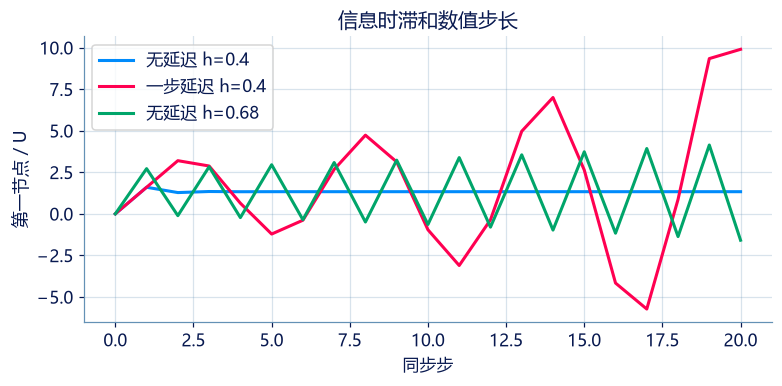

In [4]:
W=[[0.,1.,0.],[1.,0.,1.],[0.,1.,0.]];initial=[0.,4.,0.]
no=np.asarray(consensus_path(initial,W,.4,20));delay=np.asarray(delayed_consensus([initial,initial],W,.4,1,20));large=np.asarray(consensus_path(initial,W,.68,20))
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(no[:,0],label="无延迟 h=0.4",color=BLUE);ax.plot(delay[:,0],label="一步延迟 h=0.4",color=PINK);ax.plot(large[:,0],label="无延迟 h=0.68",color=GREEN);ax.set(xlabel="同步步",ylabel="第一节点 / U",title="信息时滞和数值步长");ax.legend();ax.grid(alpha=.25);plt.show()

## 结果解释

无延迟 h=0.68 已超出路径图的基础谱条件；延迟 h=0.4 的暂态（transient）也与无延迟不同。有限步曲线只能指示问题，不能替代延迟模型的特征根分析。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
np.testing.assert_allclose(delayed_consensus([initial],W,.4,0,3),consensus_path(initial,W,.4,3))
np.testing.assert_allclose(delay.sum(axis=1),4.,atol=1e-12)
assert abs(large[-1,0]-4/3)>abs(no[-1,0]-4/3)
print("零延迟极限、总和与过大步长反例通过。")

零延迟极限、总和与过大步长反例通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：延迟更新读取什么

x_{n+1}=x_n-hLx_{n-d} 中，哪个状态（state）用于差分耦合？

- **A.** 未来 x_{n+1}。
- **B.** 固定目标状态。
- **C.** 历史 x_{n-d}，同时保留当前 x_n 作为基底。
- **D.** 只看自己的当前状态。

[作答：延迟更新读取什么](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/practice/?question=p16-delay-formula)

### 第 2 题 · 单项选择题：无延迟谱界

无延迟（delay）的 h<2/λmax(L) 能直接保证任意延迟下收敛吗？

- **A.** 能，因为总和守恒。
- **B.** 能，因为图无向。
- **C.** 能，因为只延迟一步。
- **D.** 不能；延迟系统需独立稳定分析。

[作答：无延迟谱界](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/practice/?question=p16-delay-condition)

### 第 3 题 · Python 计算题：一轮延迟邻居更新

历史按 x_-d 到 x_0 排列；每步以当前 x 作基底，用 d 步前状态（state）算邻居差。

**函数与代码模板**

```python
def solve(
    history: list[list[float]],
    weights: list[list[float]],
    h: float,
    delay: int,
    steps: int,
) -> list[list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[float]]` | 长度为 delay+1 的旧状态序列。 | U |
| `weights` | `list[list[float]]` | 无向边权。 | 1/T |
| `h` | `float` | 步长。 | T |
| `delay` | `int` | 整数延迟（delay）。 | 步 |
| `steps` | `int` | 未来更新次数。 | 步 |

**返回值**

直接返回 states（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[list[float]]` | 从当前状态起的完整新路径。 | U |

**计算规则**

history 从 x_-delay 到 x_0；下一步用当前 x 作基底，用 x_-delay 计算全部邻居差，然后推进历史。

**约束与边界**

- 2—10 个节点，0≤delay≤10；history 长度为 delay+1，0≤steps≤100；矩阵（matrix）对称、非负、零对角，h>0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| history | 长度为 delay+1 的旧状态序列。 | [[0.0, 2.0], [1.0, 1.0]] | U |
| weights | 无向边权。 | [[0.0, 1.0], [1.0, 0.0]] | 1/T |
| h | 步长。 | 0.25 | T |
| delay | 整数延迟（delay）。 | 1 | 步 |
| steps | 未来更新次数。 | 1 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
history = [[0.0, 2.0], [1.0, 1.0]]
weights = [[0.0, 1.0], [1.0, 0.0]]
h = 0.25
delay = 1
steps = 1

result = solve(history, weights, h, delay, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 从当前状态起的完整新路径。 | [[1.0, 1.0], [1.5, 0.5]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[1.0, 1.0], [1.5, 0.5]]
```

**样例解释**

首例当前[1,1]不产生即时差，但用旧[0,2]得下一状态[1.5,0.5]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：一轮延迟邻居更新](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/practice/?question=p16-delayed-update)

### 第 4 题 · Python 计算题：零延迟的退化检查

给定 delay=0，延迟（delay）公式应与普通局部更新逐步一致。

**函数与代码模板**

```python
def solve(
    history: list[list[float]],
    weights: list[list[float]],
    h: float,
    delay: int,
    steps: int,
) -> list[list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[float]]` | 仅一行当前状态（state）。 | U |
| `weights` | `list[list[float]]` | 无向边权。 | 1/T |
| `h` | `float` | 步长。 | T |
| `delay` | `int` | 本题限定为0。 | 步 |
| `steps` | `int` | 更新次数。 | 步 |

**返回值**

直接返回 states（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[list[float]]` | 当前至未来的路径。 | U |

**计算规则**

history 从 x_-delay 到 x_0；下一步用当前 x 作基底，用 x_-delay 计算全部邻居差，然后推进历史。

**约束与边界**

- 2—10 个节点，0≤delay≤10；history 长度为 delay+1，0≤steps≤100；矩阵（matrix）对称、非负、零对角，h>0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| history | 仅一行当前状态（state）。 | [[0.0, 2.0]] | U |
| weights | 无向边权。 | [[0.0, 1.0], [1.0, 0.0]] | 1/T |
| h | 步长。 | 0.25 | T |
| delay | 本题限定为0。 | 0 | 步 |
| steps | 更新次数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
history = [[0.0, 2.0]]
weights = [[0.0, 1.0], [1.0, 0.0]]
h = 0.25
delay = 0
steps = 2

result = solve(history, weights, h, delay, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 当前至未来的路径。 | [[0.0, 2.0], [0.5, 1.5], [0.75, 1.25]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.0, 2.0], [0.5, 1.5], [0.75, 1.25]]
```

**样例解释**

首例退化为普通一致性更新，依次[0,2]、[0.5,1.5]、[0.75,1.25]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：零延迟的退化检查](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/practice/?question=p16-delay-zero)

**进一步阅读**

[Olfati-Saber 等](https://www.cds.caltech.edu/~murray/papers/2007c_ofm07-ieeeproc.html)讨论通信延迟与图结构；本节是固定三节点教学模型。